<a href="https://colab.research.google.com/github/eshwar-7419/cads/blob/main/CARC_IDS_Phase2A_Threat_Drift_Mapping_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2A — Threat & Drift Mapping
## CARC-IDS/IPS: Establishing a defensible continual-learning stream

This notebook is the **dataset-analysis stage before continual learning**.

The goal is NOT to train the proposed adaptive IDS/IPS yet.

Instead, we determine whether the supplied UNSW-NB15 `temporal` data actually contains:

- meaningful changes in attack prevalence;
- changes in attack-family composition;
- new versus retained attack categories;
- benign-distribution drift;
- attack-distribution drift;
- feature-distribution drift;
- candidate sequential learning boundaries.

### Why this matters

We previously observed:

- early segments dominated by benign traffic;
- middle segments containing mixed traffic;
- later segments dominated by attacks.

That alone is **not sufficient evidence of concept drift**.

We therefore separate:

1. **class-prevalence shift**;
2. **attack-family shift**;
3. **feature-distribution shift**.

Only after this analysis will we define the continual-learning tasks.

### Experimental rule

The final UNSW-NB15 test set is **not used to construct the continual-learning stream**.

Only the supplied training split is analyzed for task construction.


In [1]:
# 1. Install dependencies
!pip -q install datasets scipy pandas numpy matplotlib seaborn scikit-learn

print("Dependencies installed.")


Dependencies installed.


In [2]:
# 2. Imports and reproducibility

import json
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

BASE = Path("/content/carc_ids_phase2a")
RESULTS = BASE / "results"
FIGURES = BASE / "figures"

for p in [RESULTS, FIGURES]:
    p.mkdir(parents=True, exist_ok=True)

print("Working directory:", BASE)


Working directory: /content/carc_ids_phase2a


## 3. Load the exact dataset used in Phase 1B

We retain:

```python
lacg030175/UNSW-NB15
```

with:

```python
temporal
```

configuration.

The final test set is loaded only for documentation/integrity reporting and is **not used for task construction or drift scoring**.


In [3]:
# 3. Load UNSW-NB15 temporal configuration

ds = load_dataset(
    "lacg030175/UNSW-NB15",
    "temporal"
)

train_df = ds["train"].to_pandas()
test_df = ds["test"].to_pandas()

print("Train:", train_df.shape)
print("Test :", test_df.shape)

print("\nTrain columns:")
print(train_df.columns.tolist())


README.md:   0%|          | 0.00/5.32k [00:00<?, ?B/s]

temporal/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 12.7MB            

temporal/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

temporal/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 6.25MB            

temporal/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/175341 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/82332 [00:00<?, ? examples/s]

Train: (175341, 44)
Test : (82332, 44)

Train columns:
['ackdat', 'attack_cat', 'ct_dst_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_flw_http_mthd', 'ct_ftp_cmd', 'ct_src_dport_ltm', 'ct_src_ltm', 'ct_srv_dst', 'ct_srv_src', 'ct_state_ttl', 'dbytes', 'Dintpkt', 'djit', 'dload', 'dloss', 'dmeansz', 'Dpkts', 'dtcpb', 'dttl', 'dur', 'dwin', 'is_ftp_login', 'is_sm_ips_ports', 'label', 'proto', 'rate', 'response_body_len', 'sbytes', 'service', 'Sintpkt', 'Sjit', 'sload', 'sloss', 'smeansz', 'Spkts', 'state', 'stcpb', 'sttl', 'swin', 'synack', 'tcprtt', 'trans_depth']


In [4]:
# 4. Basic dataset integrity

print("Training labels:")
display(train_df["label"].value_counts(dropna=False).sort_index().rename("count").to_frame())

if "attack_cat" in train_df.columns:
    print("\nAttack categories:")
    display(train_df["attack_cat"].value_counts(dropna=False).rename("count").to_frame())

print("\nTest labels:")
display(test_df["label"].value_counts(dropna=False).sort_index().rename("count").to_frame())


Training labels:


,count
label,
0,56000
1,119341



Attack categories:


,count
attack_cat,
Normal,56000
Generic,40000
Exploits,33393
Fuzzers,18184
DoS,12264
Reconnaissance,10491
Analysis,2000
Backdoor,1746
Shellcode,1133



Test labels:


,count
label,
0,37000
1,45332


# 5. Define the sequential segments

The Phase-1B diagnostic divided the training sequence into 10 equal sequential segments.

We retain that same segmentation so the analysis is directly comparable with the evidence already generated.

**Important:** equal-size segments are an analysis device. They are not yet declared to be continual-learning tasks.


In [5]:
# 5. Create the same 10 sequential segments

N_SEGMENTS = 10

segment_indices = np.array_split(np.arange(len(train_df)), N_SEGMENTS)

segments = {
    i + 1: train_df.iloc[idx].copy()
    for i, idx in enumerate(segment_indices)
}

segment_summary = []

for sid, df in segments.items():
    n = len(df)
    attack_n = int((df["label"] == 1).sum())
    benign_n = int((df["label"] == 0).sum())

    segment_summary.append({
        "segment": sid,
        "rows": n,
        "benign": benign_n,
        "attack": attack_n,
        "benign_pct": benign_n / n,
        "attack_pct": attack_n / n
    })

segment_summary_df = pd.DataFrame(segment_summary)

display(segment_summary_df.round(4))

segment_summary_df.to_csv(
    RESULTS / "segment_class_distribution.csv",
    index=False
)


,segment,rows,benign,attack,benign_pct,attack_pct
0,1,17535,17535,0,1.0000,0.0000
1,2,17534,17534,0,1.0000,0.0000
2,3,17534,12842,4692,0.7324,0.2676
3,4,17534,799,16735,0.0456,0.9544
4,5,17534,2438,15096,0.1390,0.8610
5,6,17534,2168,15366,0.1236,0.8764
6,7,17534,2684,14850,0.1531,0.8469
7,8,17534,0,17534,0.0000,1.0000
8,9,17534,0,17534,0.0000,1.0000
9,10,17534,0,17534,0.0000,1.0000


# 6. Attack-family composition

This is the most important next diagnostic.

We calculate, for each segment:

- number of attack categories present;
- category counts;
- category proportions;
- categories appearing for the first time;
- categories disappearing;
- categories retained from the previous segment.

We **do not assume** that a category appearing in a later segment represents a genuinely novel cyber threat. It is only a **newly observed category within this dataset stream**.


In [6]:
# 6. Normalize attack-category labels

if "attack_cat" not in train_df.columns:
    raise KeyError(
        "The dataset does not contain 'attack_cat'. "
        "Attack-family mapping cannot be performed from this file."
    )

def normalize_category(x):
    if pd.isna(x):
        return "Unknown"
    return str(x).strip()

for sid in segments:
    segments[sid]["attack_cat_norm"] = segments[sid]["attack_cat"].apply(normalize_category)

# Category counts per segment
category_counts = pd.crosstab(
    pd.Series(
        np.concatenate([
            np.full(len(segments[sid]), sid)
            for sid in segments
        ]),
        name="segment"
    ),
    pd.concat(
        [segments[sid]["attack_cat_norm"] for sid in segments],
        ignore_index=True
    )
)

category_counts = category_counts.reindex(
    index=range(1, N_SEGMENTS + 1),
    fill_value=0
)

print("Attack-category counts by segment:")
display(category_counts)


Attack-category counts by segment:


attack_cat_norm,Analysis,Backdoor,DoS,Exploits,Fuzzers,Generic,Normal,Reconnaissance,Shellcode,Worms
segment,,,,,,,,,,
1,0,0,0,0,0,0,17535,0,0,0
2,0,0,0,0,0,0,17534,0,0,0
3,227,274,379,1436,1892,0,12842,412,68,4
4,396,182,2341,7549,3799,0,799,2200,239,29
5,425,349,2487,6505,3088,0,2438,2014,202,26
6,330,325,2428,6445,3393,0,2168,2189,228,28
7,281,287,2247,5409,2431,2376,2684,1626,173,20
8,150,155,1095,2523,1401,11241,0,863,94,12
9,105,101,770,1870,1105,12890,0,624,63,6


In [7]:
# 7. Attack-category proportions within ATTACK traffic

category_props = category_counts.copy().astype(float)

for sid in category_props.index:
    total_attack = category_props.loc[sid].sum()
    if total_attack > 0:
        category_props.loc[sid] /= total_attack

print("Attack-category proportions among attack samples:")
display(category_props.round(4))

category_counts.to_csv(RESULTS / "attack_category_counts_by_segment.csv")
category_props.to_csv(RESULTS / "attack_category_proportions_by_segment.csv")


Attack-category proportions among attack samples:


attack_cat_norm,Analysis,Backdoor,DoS,Exploits,Fuzzers,Generic,Normal,Reconnaissance,Shellcode,Worms
segment,,,,,,,,,,
1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
2,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
3,0.0129,0.0156,0.0216,0.0819,0.1079,0.0000,0.7324,0.0235,0.0039,0.0002
4,0.0226,0.0104,0.1335,0.4305,0.2167,0.0000,0.0456,0.1255,0.0136,0.0017
5,0.0242,0.0199,0.1418,0.3710,0.1761,0.0000,0.1390,0.1149,0.0115,0.0015
6,0.0188,0.0185,0.1385,0.3676,0.1935,0.0000,0.1236,0.1248,0.0130,0.0016
7,0.0160,0.0164,0.1282,0.3085,0.1386,0.1355,0.1531,0.0927,0.0099,0.0011
8,0.0086,0.0088,0.0625,0.1439,0.0799,0.6411,0.0000,0.0492,0.0054,0.0007
9,0.0060,0.0058,0.0439,0.1066,0.0630,0.7351,0.0000,0.0356,0.0036,0.0003


In [8]:
# 8. First appearance, retention, and disappearance

all_categories = sorted(category_counts.columns)

first_seen = {}
last_seen = {}

for cat in all_categories:
    present_segments = [
        sid for sid in category_counts.index
        if category_counts.loc[sid, cat] > 0
    ]

    if present_segments:
        first_seen[cat] = min(present_segments)
        last_seen[cat] = max(present_segments)

category_lifecycle = pd.DataFrame([
    {
        "attack_category": cat,
        "first_segment": first_seen[cat],
        "last_segment": last_seen[cat],
        "segments_present": int(
            (category_counts[cat] > 0).sum()
        )
    }
    for cat in all_categories
])

display(category_lifecycle.sort_values(
    ["first_segment", "attack_category"]
).reset_index(drop=True))

category_lifecycle.to_csv(
    RESULTS / "attack_category_lifecycle.csv",
    index=False
)


,attack_category,first_segment,last_segment,segments_present
0,Normal,1,7,7
1,Analysis,3,10,8
2,Backdoor,3,10,8
3,DoS,3,10,8
4,Exploits,3,10,8
5,Fuzzers,3,10,8
6,Reconnaissance,3,10,8
7,Shellcode,3,10,8
8,Worms,3,10,8
9,Generic,7,10,4


In [9]:
# 9. New / retained / disappeared categories between adjacent segments

transition_rows = []

for sid in range(2, N_SEGMENTS + 1):
    prev_set = set(
        category_counts.columns[
            category_counts.loc[sid - 1] > 0
        ]
    )
    curr_set = set(
        category_counts.columns[
            category_counts.loc[sid] > 0
        ]
    )

    new_categories = sorted(curr_set - prev_set)
    retained_categories = sorted(curr_set & prev_set)
    disappeared_categories = sorted(prev_set - curr_set)

    transition_rows.append({
        "from_segment": sid - 1,
        "to_segment": sid,
        "new_categories": ", ".join(new_categories),
        "retained_categories": ", ".join(retained_categories),
        "disappeared_categories": ", ".join(disappeared_categories),
        "n_new": len(new_categories),
        "n_retained": len(retained_categories),
        "n_disappeared": len(disappeared_categories)
    })

transition_df = pd.DataFrame(transition_rows)

display(transition_df)

transition_df.to_csv(
    RESULTS / "attack_category_transitions.csv",
    index=False
)


,from_segment,to_segment,new_categories,retained_categories,disappeared_categories,n_new,n_retained,n_disappeared
0,1,2,,Normal,,0,1,0
1,2,3,"Analysis, Backdoor, DoS, Exploits, Fuzzers, Re...",Normal,,8,1,0
2,3,4,,"Analysis, Backdoor, DoS, Exploits, Fuzzers, No...",,0,9,0
3,4,5,,"Analysis, Backdoor, DoS, Exploits, Fuzzers, No...",,0,9,0
4,5,6,,"Analysis, Backdoor, DoS, Exploits, Fuzzers, No...",,0,9,0
5,6,7,Generic,"Analysis, Backdoor, DoS, Exploits, Fuzzers, No...",,1,9,0
6,7,8,,"Analysis, Backdoor, DoS, Exploits, Fuzzers, Ge...",Normal,0,9,1
7,8,9,,"Analysis, Backdoor, DoS, Exploits, Fuzzers, Ge...",,0,9,0
8,9,10,,"Analysis, Backdoor, DoS, Exploits, Fuzzers, Ge...",,0,9,0


# 10. Attack-family drift using Jensen–Shannon divergence

For adjacent segments we compare the **attack-category distributions conditional on attack traffic**.

Jensen–Shannon divergence is used because it is symmetric and bounded.

Interpretation:

- 0 → identical category distributions;
- larger values → greater distributional difference.

This is a **drift indicator**, not proof of concept drift.


In [10]:
# 10. Jensen-Shannon divergence of attack-family distributions

def js_divergence(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    p = p / p.sum() if p.sum() else np.ones_like(p) / len(p)
    q = q / q.sum() if q.sum() else np.ones_like(q) / len(q)

    # scipy returns Jensen-Shannon distance; square it for divergence.
    return float(jensenshannon(p, q, base=2) ** 2)

attack_js_rows = []

for sid in range(2, N_SEGMENTS + 1):
    p = category_props.loc[sid - 1].to_numpy()
    q = category_props.loc[sid].to_numpy()

    attack_js_rows.append({
        "from_segment": sid - 1,
        "to_segment": sid,
        "attack_category_js_divergence": js_divergence(p, q)
    })

attack_js_df = pd.DataFrame(attack_js_rows)

display(attack_js_df.round(6))

attack_js_df.to_csv(
    RESULTS / "attack_category_js_drift.csv",
    index=False
)


,from_segment,to_segment,attack_category_js_divergence
0,1,2,0.000000
1,2,3,0.148765
2,3,4,0.434917
3,4,5,0.022443
4,5,6,0.001089
5,6,7,0.076206
6,7,8,0.248786
7,8,9,0.007578
8,9,10,0.001789


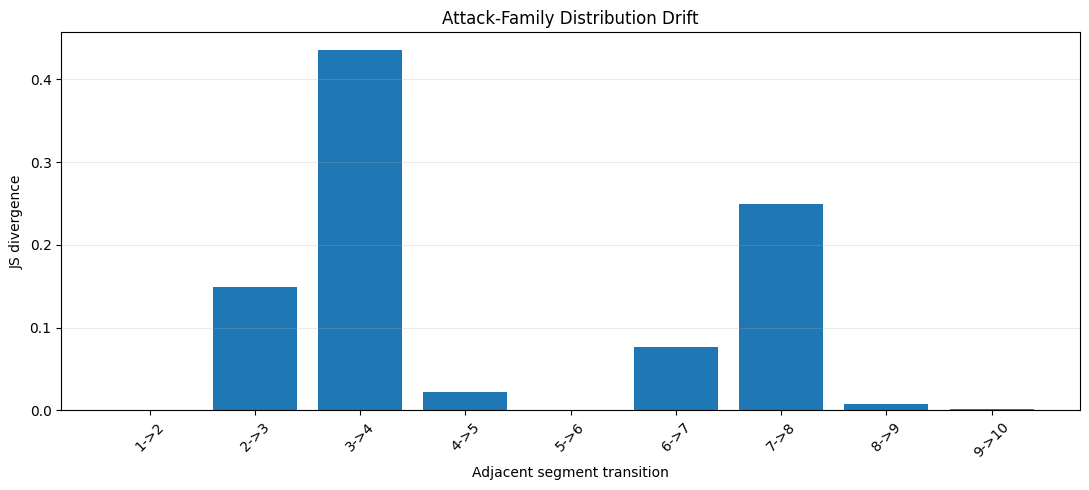

In [11]:
# 11. Plot attack-family drift

fig, ax = plt.subplots(figsize=(11, 5))

labels = [
    f"{r.from_segment}->{r.to_segment}"
    for r in attack_js_df.itertuples()
]

ax.bar(labels, attack_js_df["attack_category_js_divergence"])
ax.set_xlabel("Adjacent segment transition")
ax.set_ylabel("JS divergence")
ax.set_title("Attack-Family Distribution Drift")
ax.grid(axis="y", alpha=0.25)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES / "attack_family_js_drift.png", dpi=160)
plt.show()


# 12. Feature-distribution drift

Attack-family drift alone does not prove that the feature representation has changed.

We therefore compare numeric feature distributions between adjacent segments.

We use:

- **Jensen–Shannon divergence** on histogram-normalized distributions;
- **Wasserstein distance** as an additional distributional measure.

To avoid making the analysis computationally excessive, we first select numeric features with sufficient variation.


In [12]:
# 12. Select numeric features

DROP_FOR_DRIFT = [
    "label",
    "attack_cat",
    "attack_cat_norm",
    "id",
    "ID",
    "index"
]

numeric_features = [
    c for c in train_df.columns
    if c not in DROP_FOR_DRIFT
    and pd.api.types.is_numeric_dtype(train_df[c])
]

# Remove constant/near-constant columns
useful_numeric_features = []

for c in numeric_features:
    if train_df[c].nunique(dropna=True) >= 5:
        useful_numeric_features.append(c)

print("Numeric features:", len(numeric_features))
print("Useful numeric features:", len(useful_numeric_features))
print(useful_numeric_features)


Numeric features: 39
Useful numeric features: 36
['ackdat', 'ct_dst_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_flw_http_mthd', 'ct_src_dport_ltm', 'ct_src_ltm', 'ct_srv_dst', 'ct_srv_src', 'ct_state_ttl', 'dbytes', 'Dintpkt', 'djit', 'dload', 'dloss', 'dmeansz', 'Dpkts', 'dtcpb', 'dttl', 'dur', 'dwin', 'rate', 'response_body_len', 'sbytes', 'Sintpkt', 'Sjit', 'sload', 'sloss', 'smeansz', 'Spkts', 'stcpb', 'sttl', 'swin', 'synack', 'tcprtt', 'trans_depth']


In [13]:
# 13. Robust JS + Wasserstein feature drift functions

def numeric_js(p, q, bins=20):
    combined = np.concatenate([
        p[np.isfinite(p)],
        q[np.isfinite(q)]
    ])

    if len(combined) == 0:
        return np.nan

    lo, hi = np.percentile(combined, [1, 99])

    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return 0.0

    p_clip = np.clip(p, lo, hi)
    q_clip = np.clip(q, lo, hi)

    hist_p, edges = np.histogram(p_clip, bins=bins, range=(lo, hi), density=False)
    hist_q, _ = np.histogram(q_clip, bins=edges, density=False)

    hist_p = hist_p.astype(float) + 1e-12
    hist_q = hist_q.astype(float) + 1e-12

    hist_p /= hist_p.sum()
    hist_q /= hist_q.sum()

    return js_divergence(hist_p, hist_q)

def robust_wasserstein(p, q):
    p = p[np.isfinite(p)]
    q = q[np.isfinite(q)]

    if len(p) == 0 or len(q) == 0:
        return np.nan

    # Normalize robustly so scale differences do not dominate across unrelated features.
    combined = np.concatenate([p, q])
    lo, hi = np.percentile(combined, [1, 99])

    if hi <= lo:
        return 0.0

    p = np.clip(p, lo, hi)
    q = np.clip(q, lo, hi)

    # Robust scale normalization
    return float(wasserstein_distance(p, q) / (hi - lo + 1e-12))


In [14]:
# 14. Calculate feature drift for adjacent segments

feature_drift_rows = []

for sid in range(2, N_SEGMENTS + 1):
    prev = segments[sid - 1]
    curr = segments[sid]

    for feature in useful_numeric_features:
        p = pd.to_numeric(prev[feature], errors="coerce").to_numpy(dtype=float)
        q = pd.to_numeric(curr[feature], errors="coerce").to_numpy(dtype=float)

        feature_drift_rows.append({
            "from_segment": sid - 1,
            "to_segment": sid,
            "feature": feature,
            "js_divergence": numeric_js(p, q),
            "wasserstein_normalized": robust_wasserstein(p, q)
        })

feature_drift_df = pd.DataFrame(feature_drift_rows)

print("Feature-drift records:", len(feature_drift_df))
display(feature_drift_df.head(20))

feature_drift_df.to_csv(
    RESULTS / "numeric_feature_drift.csv",
    index=False
)


Feature-drift records: 324


,from_segment,to_segment,feature,js_divergence,wasserstein_normalized
0,1,2,ackdat,0.003439,0.014025
1,1,2,ct_dst_ltm,0.028844,0.059048
2,1,2,ct_dst_sport_ltm,0.000180,0.004618
3,1,2,ct_dst_src_ltm,0.015553,0.039822
4,1,2,ct_flw_http_mthd,0.000048,0.004842
5,1,2,ct_src_dport_ltm,0.061678,0.076003
6,1,2,ct_src_ltm,0.045925,0.070418
7,1,2,ct_srv_dst,0.013944,0.036913
8,1,2,ct_srv_src,0.014460,0.036273
9,1,2,ct_state_ttl,0.001178,0.011861


In [15]:
# 15. Summarize feature drift by segment transition

feature_transition_summary = (
    feature_drift_df
    .groupby(["from_segment", "to_segment"])
    .agg(
        mean_js=("js_divergence", "mean"),
        median_js=("js_divergence", "median"),
        max_js=("js_divergence", "max"),
        mean_wasserstein=("wasserstein_normalized", "mean"),
        median_wasserstein=("wasserstein_normalized", "median"),
        max_wasserstein=("wasserstein_normalized", "max")
    )
    .reset_index()
)

display(feature_transition_summary.round(6))

feature_transition_summary.to_csv(
    RESULTS / "feature_drift_transition_summary.csv",
    index=False
)


,from_segment,to_segment,mean_js,median_js,max_js,mean_wasserstein,median_wasserstein,max_wasserstein
0,1,2,0.016548,0.007222,0.095863,0.024831,0.017887,0.076003
1,2,3,0.100796,0.061744,0.419570,0.090176,0.058733,0.498202
2,3,4,0.038014,0.018883,0.189282,0.046452,0.032998,0.226210
3,4,5,0.006005,0.001867,0.029311,0.010557,0.004954,0.036107
4,5,6,0.003773,0.002717,0.017439,0.015076,0.010973,0.057077
5,6,7,0.028721,0.024253,0.099486,0.059627,0.053146,0.216197
6,7,8,0.056211,0.024896,0.191192,0.105347,0.077264,0.347074
7,8,9,0.004312,0.002723,0.020763,0.021302,0.012977,0.061312
8,9,10,0.001983,0.000862,0.008062,0.007750,0.005889,0.033988


In [16]:
# 16. Identify the most drifting features

top_feature_drift = (
    feature_drift_df
    .groupby("feature")
    .agg(
        mean_js=("js_divergence", "mean"),
        max_js=("js_divergence", "max"),
        mean_wasserstein=("wasserstein_normalized", "mean"),
        max_wasserstein=("wasserstein_normalized", "max")
    )
    .sort_values("mean_js", ascending=False)
)

display(top_feature_drift.head(20).round(6))

top_feature_drift.to_csv(
    RESULTS / "top_feature_drift.csv"
)


,mean_js,max_js,mean_wasserstein,max_wasserstein
feature,,,,
sttl,0.082112,0.417035,0.116641,0.498202
ct_state_ttl,0.077606,0.419570,0.067323,0.183111
dttl,0.072381,0.405701,0.106721,0.388521
dmeansz,0.054176,0.309115,0.035802,0.156198
ct_dst_ltm,0.049938,0.174957,0.063579,0.236331
ct_src_ltm,0.049563,0.169772,0.061587,0.228915
ct_dst_src_ltm,0.044362,0.183475,0.063901,0.265434
ct_srv_dst,0.044111,0.191192,0.063715,0.267427
ct_src_dport_ltm,0.044092,0.178996,0.061277,0.244286


# 17. Class-conditional drift

A major methodological distinction:

A change in attack prevalence:

\[
P(Y)
\]

is not necessarily concept drift.

We therefore separately examine:

- benign feature drift: `P(X | Y=0)`;
- attack feature drift: `P(X | Y=1)`.

This lets us distinguish:

### Prior/class-prevalence shift

\[
P(Y) 	ext{ changes}
\]

from changes in the observed feature distributions:

\[
P(X|Y)
\]

The latter is more relevant to detector adaptation.


In [17]:
# 17. Class-conditional feature drift summary

conditional_rows = []

for sid in range(2, N_SEGMENTS + 1):
    prev = segments[sid - 1]
    curr = segments[sid]

    for class_value, class_name in [(0, "benign"), (1, "attack")]:
        prev_c = prev[prev["label"] == class_value]
        curr_c = curr[curr["label"] == class_value]

        # If either segment has no samples of the class, drift is undefined.
        if len(prev_c) < 20 or len(curr_c) < 20:
            conditional_rows.append({
                "from_segment": sid - 1,
                "to_segment": sid,
                "class": class_name,
                "n_prev": len(prev_c),
                "n_curr": len(curr_c),
                "mean_js": np.nan,
                "median_js": np.nan,
                "coverage": 0.0
            })
            continue

        values = []

        for feature in useful_numeric_features:
            p = pd.to_numeric(prev_c[feature], errors="coerce").to_numpy(dtype=float)
            q = pd.to_numeric(curr_c[feature], errors="coerce").to_numpy(dtype=float)

            js = numeric_js(p, q)
            if np.isfinite(js):
                values.append(js)

        conditional_rows.append({
            "from_segment": sid - 1,
            "to_segment": sid,
            "class": class_name,
            "n_prev": len(prev_c),
            "n_curr": len(curr_c),
            "mean_js": np.mean(values) if values else np.nan,
            "median_js": np.median(values) if values else np.nan,
            "coverage": len(values) / len(useful_numeric_features)
        })

conditional_drift_df = pd.DataFrame(conditional_rows)

display(conditional_drift_df.round(6))

conditional_drift_df.to_csv(
    RESULTS / "class_conditional_drift.csv",
    index=False
)


,from_segment,to_segment,class,n_prev,n_curr,mean_js,median_js,coverage
0,1,2,benign,17535,17534,0.016548,0.007222,1.0
1,1,2,attack,0,0,NaN,NaN,0.0
2,2,3,benign,17534,12842,0.081697,0.050644,1.0
3,2,3,attack,0,4692,NaN,NaN,0.0
4,3,4,benign,12842,799,0.089826,0.074795,1.0
5,3,4,attack,4692,16735,0.005366,0.003812,1.0
6,4,5,benign,799,2438,0.069213,0.041930,1.0
7,4,5,attack,16735,15096,0.005979,0.000699,1.0
8,5,6,benign,2438,2168,0.042131,0.021820,1.0
9,5,6,attack,15096,15366,0.003574,0.001690,1.0


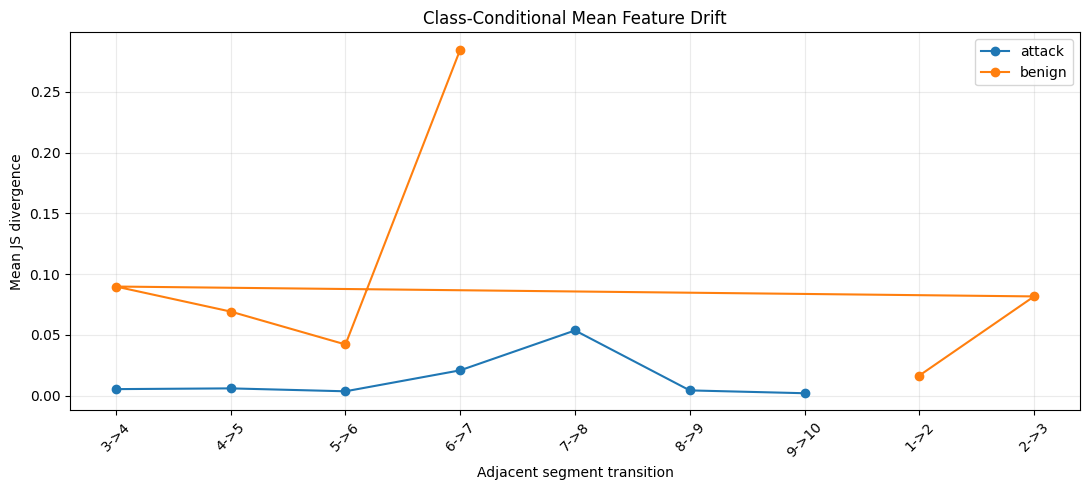

In [18]:
# 18. Visualize conditional drift

fig, ax = plt.subplots(figsize=(11, 5))

for class_name, g in conditional_drift_df.groupby("class"):
    valid = g.dropna(subset=["mean_js"])
    if len(valid):
        labels = [
            f"{r.from_segment}->{r.to_segment}"
            for r in valid.itertuples()
        ]
        ax.plot(
            labels,
            valid["mean_js"],
            marker="o",
            label=class_name
        )

ax.set_title("Class-Conditional Mean Feature Drift")
ax.set_xlabel("Adjacent segment transition")
ax.set_ylabel("Mean JS divergence")
ax.grid(alpha=0.25)
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES / "class_conditional_drift.png", dpi=160)
plt.show()


# 19. Candidate continual-learning boundaries

We now combine the evidence.

A transition is more interesting for continual learning when one or more of these occur:

1. attack prevalence changes substantially;
2. new attack categories appear;
3. attack-family composition changes substantially;
4. numeric feature distributions shift;
5. class-conditional feature distributions shift.

### Important

We do **not** automatically label a transition as a task boundary.

The score below is only a **candidate-boundary ranking tool**.

The final task design must be inspected manually from the evidence.


In [19]:
# 19. Build candidate-boundary evidence table

candidate = segment_summary_df.copy()

# Attack-prevalence shift
candidate["prev_attack_pct"] = candidate["attack_pct"].shift(1)
candidate["attack_prevalence_abs_change"] = (
    candidate["attack_pct"] - candidate["prev_attack_pct"]
).abs()

# Merge attack-family drift
candidate = candidate.merge(
    attack_js_df.rename(columns={"to_segment": "segment"}),
    on="segment",
    how="left"
)

# Merge feature drift
candidate = candidate.merge(
    feature_transition_summary.rename(columns={"to_segment": "segment"}),
    on="segment",
    how="left"
)

# New category count
new_counts = transition_df[[
    "to_segment", "n_new", "n_retained", "n_disappeared"
]].rename(columns={"to_segment": "segment"})

candidate = candidate.merge(
    new_counts,
    on="segment",
    how="left"
)

candidate["n_new"] = candidate["n_new"].fillna(0)
candidate["n_retained"] = candidate["n_retained"].fillna(0)
candidate["n_disappeared"] = candidate["n_disappeared"].fillna(0)

# A transparent, ordinal candidate score.
# This is NOT a learned or validated drift detector.
candidate["boundary_evidence_score"] = (
    (candidate["attack_prevalence_abs_change"] >= 0.25).astype(int)
    + (candidate["attack_category_js_divergence"] >= 0.10).astype(int)
    + (candidate["mean_js"] >= 0.05).astype(int)
    + (candidate["n_new"] > 0).astype(int)
)

display(
    candidate[
        [
            "segment",
            "attack_pct",
            "attack_prevalence_abs_change",
            "attack_category_js_divergence",
            "mean_js",
            "median_js",
            "n_new",
            "n_retained",
            "n_disappeared",
            "boundary_evidence_score"
        ]
    ].round(6)
)

candidate.to_csv(
    RESULTS / "candidate_boundary_evidence.csv",
    index=False
)


,segment,attack_pct,attack_prevalence_abs_change,attack_category_js_divergence,mean_js,median_js,n_new,n_retained,n_disappeared,boundary_evidence_score
0,1,0.000000,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0
1,2,0.000000,0.000000,0.000000,0.016548,0.007222,0.0,1.0,0.0,0
2,3,0.267594,0.267594,0.148765,0.100796,0.061744,8.0,1.0,0.0,4
3,4,0.954431,0.686837,0.434917,0.038014,0.018883,0.0,9.0,0.0,2
4,5,0.860956,0.093476,0.022443,0.006005,0.001867,0.0,9.0,0.0,0
5,6,0.876355,0.015399,0.001089,0.003773,0.002717,0.0,9.0,0.0,0
6,7,0.846926,0.029429,0.076206,0.028721,0.024253,1.0,9.0,0.0,1
7,8,1.000000,0.153074,0.248786,0.056211,0.024896,0.0,9.0,1.0,2
8,9,1.000000,0.000000,0.007578,0.004312,0.002723,0.0,9.0,0.0,0
9,10,1.000000,0.000000,0.001789,0.001983,0.000862,0.0,9.0,0.0,0


# 20. Do NOT automatically create tasks yet

The output above provides evidence for candidate boundaries.

Before Phase 2, inspect:

- `attack_category_transitions.csv`
- `attack_category_lifecycle.csv`
- `attack_category_js_drift.csv`
- `feature_drift_transition_summary.csv`
- `class_conditional_drift.csv`
- `candidate_boundary_evidence.csv`

### Decision rules

A strong candidate transition should have evidence beyond a simple attack-rate change.

For example:

```text
Attack prevalence changes
        +
Attack-family composition changes
        +
Feature distribution changes
```

is much stronger than:

```text
Attack prevalence changes only
```

If the dataset contains mostly **prior shift** rather than **conditional/concept drift**, we should explicitly design Phase 2 around that limitation rather than pretending it is something else.


In [20]:
# 21. Compact report for easy inspection

compact = candidate[[
    "segment",
    "rows",
    "benign_pct",
    "attack_pct",
    "attack_prevalence_abs_change",
    "attack_category_js_divergence",
    "mean_js",
    "median_js",
    "n_new",
    "n_retained",
    "n_disappeared",
    "boundary_evidence_score"
]].copy()

display(compact.round(4))

compact.to_csv(
    RESULTS / "phase2a_compact_drift_report.csv",
    index=False
)


,segment,rows,benign_pct,attack_pct,attack_prevalence_abs_change,attack_category_js_divergence,mean_js,median_js,n_new,n_retained,n_disappeared,boundary_evidence_score
0,1,17535,1.0000,0.0000,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0
1,2,17534,1.0000,0.0000,0.0000,0.0000,0.0165,0.0072,0.0,1.0,0.0,0
2,3,17534,0.7324,0.2676,0.2676,0.1488,0.1008,0.0617,8.0,1.0,0.0,4
3,4,17534,0.0456,0.9544,0.6868,0.4349,0.0380,0.0189,0.0,9.0,0.0,2
4,5,17534,0.1390,0.8610,0.0935,0.0224,0.0060,0.0019,0.0,9.0,0.0,0
5,6,17534,0.1236,0.8764,0.0154,0.0011,0.0038,0.0027,0.0,9.0,0.0,0
6,7,17534,0.1531,0.8469,0.0294,0.0762,0.0287,0.0243,1.0,9.0,0.0,1
7,8,17534,0.0000,1.0000,0.1531,0.2488,0.0562,0.0249,0.0,9.0,1.0,2
8,9,17534,0.0000,1.0000,0.0000,0.0076,0.0043,0.0027,0.0,9.0,0.0,0
9,10,17534,0.0000,1.0000,0.0000,0.0018,0.0020,0.0009,0.0,9.0,0.0,0


# 22. Interpretation checklist

### We are looking for three different phenomena

#### A. Prior shift

The proportion of attacks changes:

\[
P(Y)
\]

This affects alert volume but does not necessarily mean the detector's decision boundary has become obsolete.

#### B. Covariate shift

Traffic features change:

\[
P(X)
\]

while the underlying class relationship may remain similar.

#### C. Conditional/concept drift

The relationship between traffic features and the attack label changes:

\[
P(Y|X)
\]

This is the strongest justification for continual adaptation.

### Do not claim C unless the evidence supports it.

This distinction will be explicitly reported in the thesis.


In [21]:
# 23. Save a machine-readable protocol

protocol = {
    "dataset": "lacg030175/UNSW-NB15",
    "config": "temporal",
    "stream_source": "training split only",
    "final_test_used_for_task_construction": False,
    "n_segments": N_SEGMENTS,
    "segment_method": "equal-size sequential segments",
    "attack_family_drift_metric": "Jensen-Shannon divergence",
    "feature_drift_metrics": [
        "Jensen-Shannon divergence",
        "normalized Wasserstein distance"
    ],
    "conditional_drift": [
        "benign P(X|Y=0)",
        "attack P(X|Y=1)"
    ],
    "candidate_boundary_score": {
        "attack_prevalence_change_threshold": 0.25,
        "attack_category_js_threshold": 0.10,
        "mean_feature_js_threshold": 0.05,
        "new_attack_category": True
    },
    "note": "Candidate score is diagnostic only and is not a validated drift detector."
}

with open(RESULTS / "phase2a_protocol.json", "w") as f:
    json.dump(protocol, f, indent=2)

bundle = shutil.make_archive(
    str(BASE / "phase2a_drift_mapping_artifacts"),
    "zip",
    root_dir=BASE
)

print("Created:", bundle)
print("\nKey outputs:")
for p in sorted(RESULTS.glob("*")):
    print(" -", p)


Created: /content/carc_ids_phase2a/phase2a_drift_mapping_artifacts.zip

Key outputs:
 - /content/carc_ids_phase2a/results/attack_category_counts_by_segment.csv
 - /content/carc_ids_phase2a/results/attack_category_js_drift.csv
 - /content/carc_ids_phase2a/results/attack_category_lifecycle.csv
 - /content/carc_ids_phase2a/results/attack_category_proportions_by_segment.csv
 - /content/carc_ids_phase2a/results/attack_category_transitions.csv
 - /content/carc_ids_phase2a/results/candidate_boundary_evidence.csv
 - /content/carc_ids_phase2a/results/class_conditional_drift.csv
 - /content/carc_ids_phase2a/results/feature_drift_transition_summary.csv
 - /content/carc_ids_phase2a/results/numeric_feature_drift.csv
 - /content/carc_ids_phase2a/results/phase2a_compact_drift_report.csv
 - /content/carc_ids_phase2a/results/phase2a_protocol.json
 - /content/carc_ids_phase2a/results/segment_class_distribution.csv
 - /content/carc_ids_phase2a/results/top_feature_drift.csv


# 24. Phase-2A completion

After running this notebook, send these files:

1. `phase2a_compact_drift_report.csv`
2. `attack_category_transitions.csv`
3. `attack_category_lifecycle.csv`
4. `attack_category_js_drift.csv`
5. `class_conditional_drift.csv`

The results will determine the actual continual-learning task sequence.

### Next stage

Only after inspecting these results will we construct:

**Phase 2B — Continual Learning Benchmark**

with:

- Static model;
- Naive continual learning;
- Replay;
- EWC;
- forgetting;
- new-threat performance;
- old-threat retention.

The proposed Resource-Aware Adaptation Utility will be introduced only after these baselines are established.
